## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv("../data/US-pumpkins.csv")

pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [37]:
pumpkins = pumpkins[pumpkins["Package"].str.contains("bushel", case=True, regex=True)]
columns_to_select = ["Package", "Variety", "City Name", "Low Price", "High Price", "Date"]
pumpkins = pumpkins.loc[:, columns_to_select]
price = (pumpkins["Low Price"] + pumpkins["High Price"]) / 2
month = pd.DatetimeIndex(pumpkins["Date"]).month
day_of_year = pd.to_datetime(pumpkins["Date"], format="%m/%d/%y").apply(lambda dt: (dt - datetime(dt.year, 1, 1)).days)

new_pumpkins = pd.DataFrame(
    {
        "Month": month,
        "DayOfYear": day_of_year,
        "Variety": pumpkins["Variety"],
        "City": pumpkins["City Name"],
        "Package": pumpkins["Package"],
        "Low Price": pumpkins["Low Price"],
        "High Price": pumpkins["High Price"],
        "Price": price,
    }
)

new_pumpkins.loc[new_pumpkins["Package"].str.contains("1 1/9"), "Price"] = price / 1.1
new_pumpkins.loc[new_pumpkins["Package"].str.contains("1/2"), "Price"] = price * 2
new_pumpkins.head()

,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

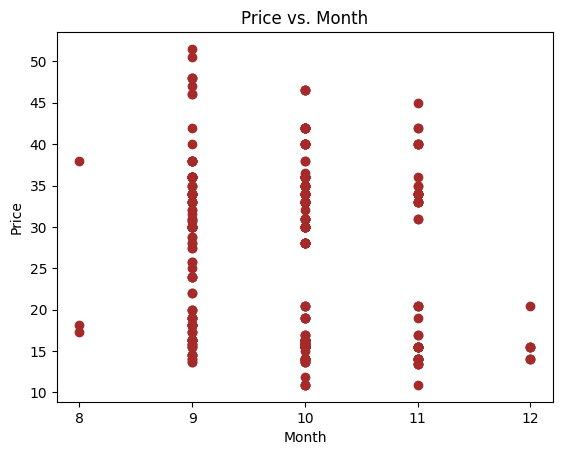

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter("Month", "Price", data=new_pumpkins, color="brown")
ax.set_xticks(range(new_pumpkins.Month.min(), new_pumpkins.Month.max() + 1))
ax.set_xlabel("Month")
ax.set_ylabel("Price")
ax.set_title("Price vs. Month")
plt.show()

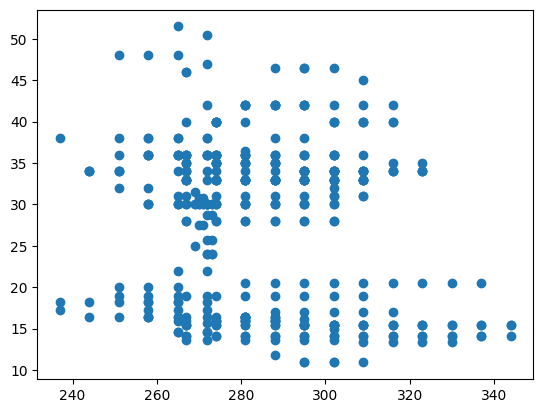

In [39]:
plt.scatter("DayOfYear", "Price", data=new_pumpkins)

Let's see if there is a correlation using the `corr` function.

In [40]:
print(f"{new_pumpkins.Month.corr(new_pumpkins.Price):.2f}")
print(f"{new_pumpkins.DayOfYear.corr(new_pumpkins.Price):.2f}")

-0.15
-0.17


Let's plot each pumpkin variety using a different color.

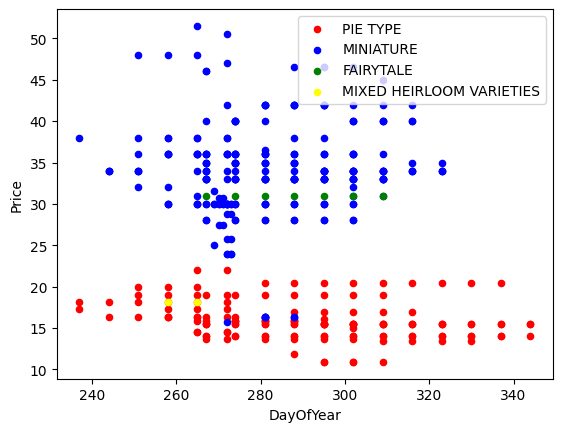

In [41]:
ax = None
colors = ["red", "blue", "green", "yellow"]

for i, var in enumerate(new_pumpkins.Variety.unique()):
    df = new_pumpkins[new_pumpkins.Variety == var]
    ax = df.plot.scatter("DayOfYear", "Price", ax=ax, c=colors[i], label=var)

The same but now using Seaborn's `relplot` function with the `hue` semantic argument.

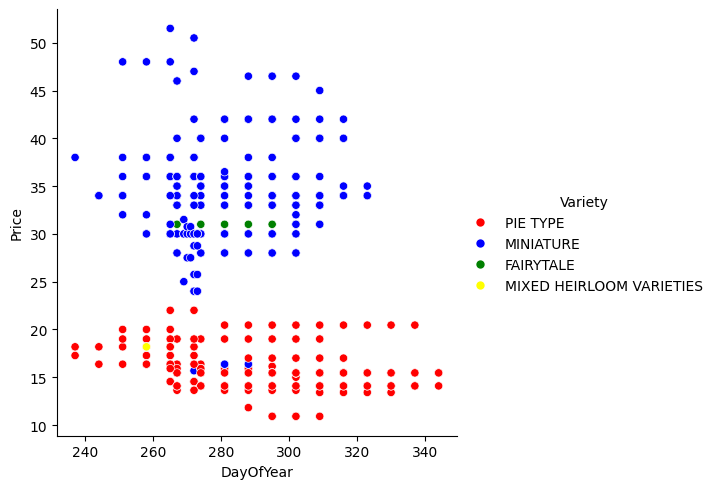

In [42]:
import seaborn as sns

sns.relplot(
    new_pumpkins,
    x="DayOfYear",
    y="Price",
    hue="Variety",
    palette=["red", "blue", "green", "yellow"],
)

It looks like variety has more effect on the overall price than the actual selling date.<br/>
Let's plot a bar graph to confirm this observation.

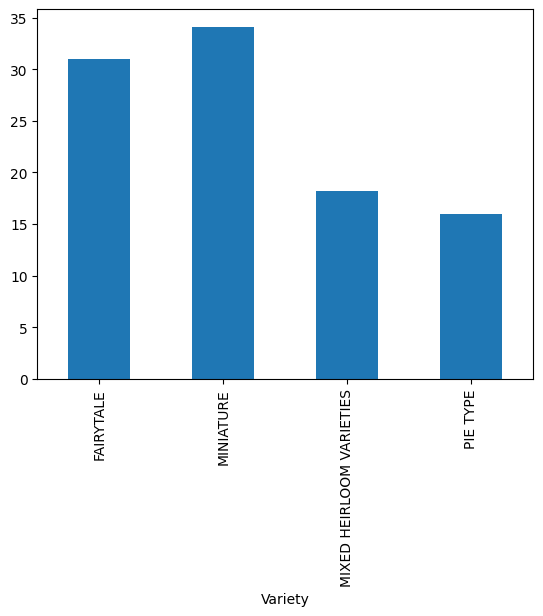

In [43]:
new_pumpkins.groupby("Variety")["Price"].mean().plot(kind="bar")
plt.show()

Let's focus on one pumpkin variety (Pie Type) and examine the effect of the date on the price of it.

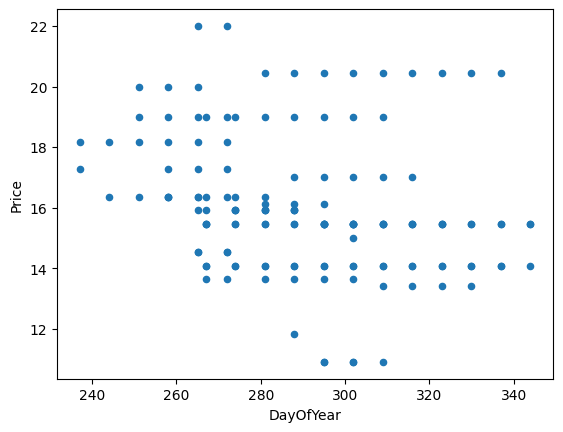

In [44]:
pie_pumpkins = new_pumpkins[new_pumpkins.Variety == "PIE TYPE"]
pie_pumpkins.plot.scatter("DayOfYear", "Price")

plt.show()

And the correlation between **Price** and **DayOfYear** is now:

In [45]:
print(f"{pie_pumpkins.Price.corr(pie_pumpkins.DayOfYear):.2f}")

-0.27


Get rid of all empty cells.

In [46]:
pie_pumpkins.dropna(inplace=True)
pie_pumpkins.info()

<class 'pandas.DataFrame'>
Index: 144 entries, 70 to 1630
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       144 non-null    int32  
 1   DayOfYear   144 non-null    int64  
 2   Variety     144 non-null    str    
 3   City        144 non-null    str    
 4   Package     144 non-null    str    
 5   Low Price   144 non-null    float64
 6   High Price  144 non-null    float64
 7   Price       144 non-null    float64
dtypes: float64(3), int32(1), int64(1), str(3)
memory usage: 9.6 KB


## Simple Linear Regression

To train our Linear Regression model, we'll use the **Scikit-learn** library.

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

Separate input values (features) from the expected output (label) into separate numpy arrays:

In [58]:
X = pie_pumpkins.DayOfYear
y = pie_pumpkins.Price

X.shape

(144,)

Note that the input values (X) is returned as a Series of values with shape (144,) i.e. 144 rows. However, the Linear Regression package expects a **2-D array** as an input, with each row representing a vector of feature values. As such, we have to **reshape** the array to a shape of **NX1** or **(N, 1)**, where N is the dataset size.

In [59]:
X = X.to_numpy().reshape(-1, 1)
X.shape

(144, 1)

Now, split the data into training and test datasets:

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Next, train the Regression model by fitting the model to our data:

In [61]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
b = lin_reg.coef_[0]
a = lin_reg.intercept_

print(f"y = {a:.3f}{b:+.3f}X")

y = 21.134-0.018X


> **NOTE:** The negative coefficient (0.018) indicates that prices drop with time - but really not that much, around 2 cents per day.<br/>
> Also, the intercept indicates the price at the beginning of the year (around 21 dollars).

## Evaluation of the Model

Measuring the accuracy of the model involves using the test dataset to predict prices and then comparing the predictions to the actual values. The metric to use is the **MSE (Mean Squared Error)**.

In [80]:
pred = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"Mean error: {rmse:.2f} ({rmse/np.mean(pred)*100:.2f}%)")

Mean error: 2.77 (17.24%)


The **Coefficient of Determination** also gives us a measure of the model quality.

In [82]:
score = lin_reg.score(X_train, y_train)
print(f"Coefficient of Determination: {score:.2f}")

Coefficient of Determination: 0.04


Plot the test data together with the regression line:

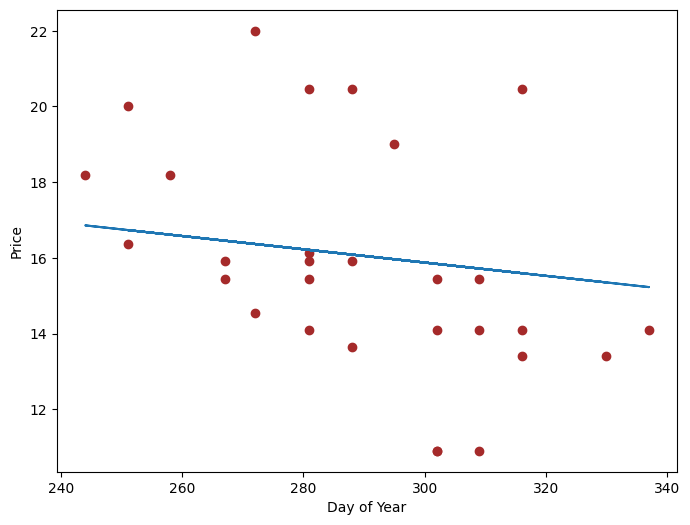

In [89]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_test, y_test, color="brown")
ax.plot(X_test, pred)
ax.set_xlabel("Day of Year")
ax.set_ylabel("Price")
plt.show()

It seems that the day of the year is not a very good predictor of pumpkin prices! Only 4% in the variation of price is explained by the day of the year. The plot above also indicates there is not a good fit between the predicted and the actual values.

## Polynomial Regression

Let's include a squared `DayOfYear` variable into input data, and fit the data with a **parabolic curve**.<br/>
We will create a **pipeline** (a chain of estimators) that first adds polynomial features to the model, and then trains the regression.

In [91]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [92]:
pred = pipeline.predict(X_test)

In [115]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
score = pipeline.score(X_train, y_train)

print(f"Mean error: {rmse:.3f} ({rmse/np.mean(pred)*100:.3f}%)")
print(f"Coefficient of Determination: {score:.3f}")

Mean error: 2.730 (17.042%)
Coefficient of Determination: 0.076


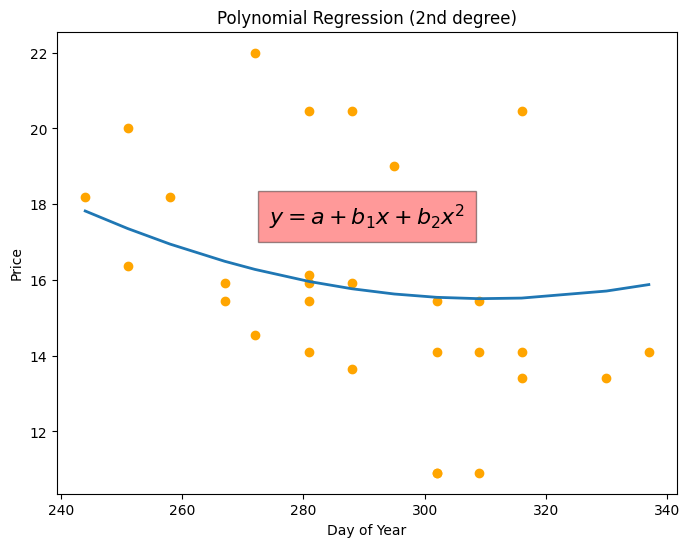

In [123]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_test, y_test, color="orange")
ax.plot(sorted(X_test), pipeline.predict(sorted(X_test)), lw=2)
ax.set_xlabel("Day of Year")
ax.set_ylabel("Price")
ax.set_title("Polynomial Regression (2nd degree)")
ax.text(
    0.5,
    0.6,
    r"$y = a + b_1x +b_2x^2$",
    fontsize=16,
    transform=ax.transAxes,
    horizontalalignment="center",
    verticalalignment="center",
    bbox={
        "facecolor": "red",
        "alpha": 0.4,
        "pad": 8,
    },
)

plt.show()

## Categorical Features
### Encoding Varieties
To take `Variety` into account, we first need to convert it to numeric form, or **encode** it.<br/>

> **One-hot encoding**: We will replace the `Variety` column with four different columns (one for each variety). Each new column will contain 1 (if the corresponding row is of this variety) or 0 otherwise.

In [ ]:
pd.get_dummies(new_pumpkins)

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


### Polynomial Regression
To make the best model use combined:
- one-hot encoded categorical columns and
- numerical columns

In [138]:
# Set up training data
X = (
    pd.get_dummies(new_pumpkins.Variety)
    .join(new_pumpkins.Month)
    .join(pd.get_dummies(new_pumpkins.City))
    .join(pd.get_dummies(new_pumpkins.Package))
)
y = new_pumpkins.Price

In [140]:
# Make train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Setup and train the pipeline
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

# Predict results for test data
pred = pipeline.predict(X_test)

# Calculate MSE and determination
mse = np.sqrt(mean_squared_error(y_test, pred))
score = pipeline.score(X_train, y_train)
print(f"Mean error: {mse:.3f} ({mse/np.mean(pred)*100:.3f})%")
print(f"Coefficient of Determination: {score:.3f}")

Mean error: 2.234 (8.276)%
Coefficient of Determination: 0.965
